In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Image size       : {X_train.shape[1]}x{X_train.shape[2]} pixels')
print(f'Classes          : {np.unique(y_train)}  (digits 0-9)')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 60000
Test samples     : 10000
Image size       : 28x28 pixels
Classes          : [0 1 2 3 4 5 6 7 8 9]  (digits 0-9)


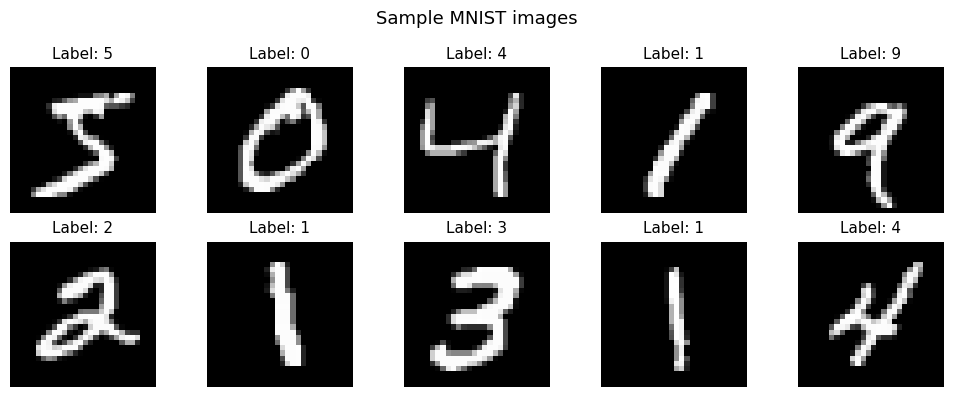

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=11)
    ax.axis('off')
plt.suptitle('Sample MNIST images', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f'X_train shape after preprocessing: {X_train.shape}')
print(f'X_test  shape after preprocessing: {X_test.shape}')

X_train shape after preprocessing: (60000, 784)
X_test  shape after preprocessing: (10000, 784)


In [ ]:
model = keras.Sequential([
    # Input layer (784 neurons)
    layers.Input(shape=(784,)),

    # Hidden layer 1
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),          # Prevent overfitting

    # Hidden layer 2
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Output layer (10 classes for digits 0-9)
    layers.Dense(10, activation='softmax')
], name='digit_ANN')

model.summary()

Model: "digit_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8788 - loss: 0.4037 - val_accuracy: 0.9632 - val_loss: 0.1302
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9442 - loss: 0.1898 - val_accuracy: 0.9710 - val_loss: 0.0993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9565 - loss: 0.1432 - val_accuracy: 0.9775 - val_loss: 0.0835
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9640 - loss: 0.1183 - val_accuracy: 0.9785 - val_loss: 0.0746
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9686 - loss: 0.1024 - val_accuracy: 0.9777 - val_loss: 0.0742
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9706 - loss: 0.0907 - val_accuracy: 0.9785 - val_loss: 0.0662
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9745 - loss: 0.0816 - val_accuracy: 0.9787 - val_loss: 0.0694
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9760 - loss: 0.0750 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n✅ Test Accuracy : {test_acc*100:.2f}%')
print(f'   Test Loss     : {test_loss:.4f}')


✅ Test Accuracy : 98.09%
   Test Loss     : 0.0702


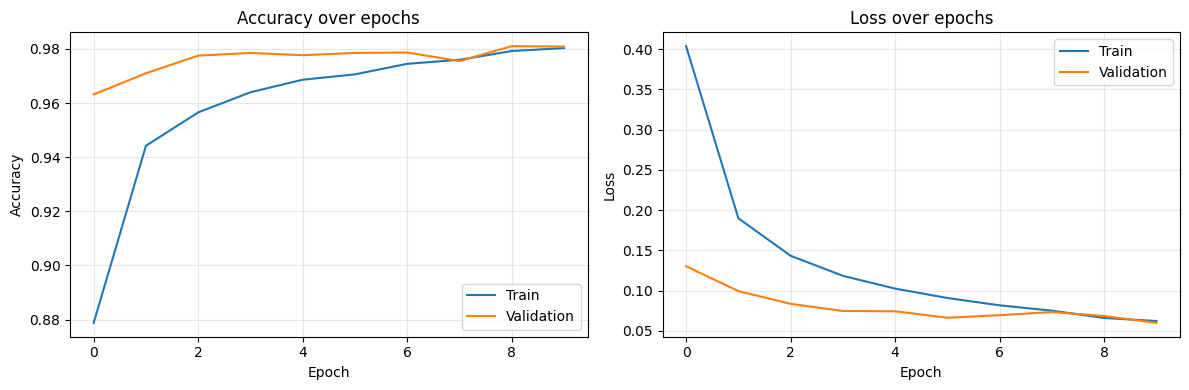

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

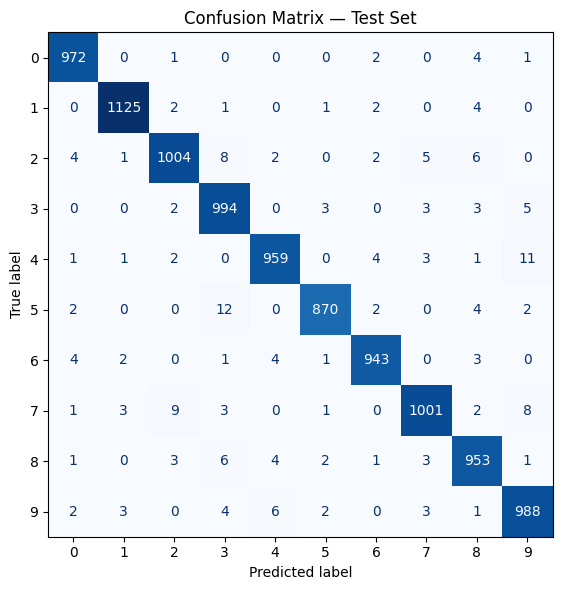

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

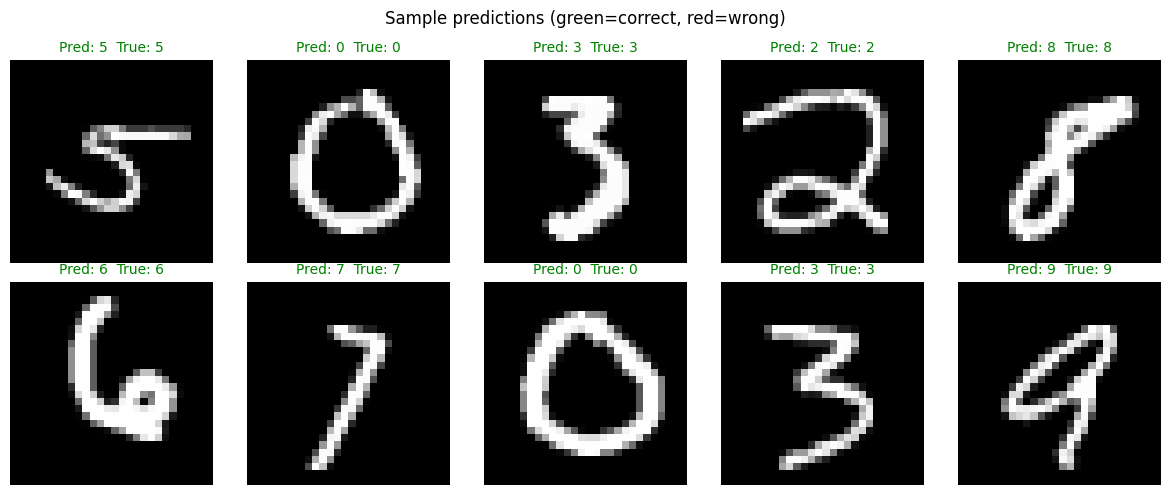

In [ ]:
indices = np.random.choice(len(X_test), 10, replace=False)
sample_images = X_test[indices]
true_labels   = y_test[indices]
predictions   = np.argmax(model.predict(sample_images, verbose=0), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    color = 'green' if predictions[i] == true_labels[i] else 'red'
    ax.set_title(f'Pred: {predictions[i]}  True: {true_labels[i]}',
                 color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
model.save('digit_recognizer_model.keras')
print('Model saved as digit_recognizer_model.keras')

Model saved as digit_recognizer_model.keras
